In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Lasso,Ridge,LinearRegression
from sklearn.svm import SVR
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor

In [2]:
!pip install catboost

  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/100.2 MB 676.8 kB/s eta 0:02:28
   ---------------------------------------- 0.5/100.2 MB 676.8 kB/s eta 0:02:28
   ---------------------------------------- 0.8/100.2 MB 692.0 kB/s eta 0:02:24
   ---------------------------------------- 0.8/100.2 MB 692.0 kB/s eta 0:02:24
   ---------------------------------------- 1.0/100.2 MB 633.9 kB/s eta 0:02:37
   -------------------------------------


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
df = pd.read_csv('data/StudentsPerformance.csv')

In [4]:
X = df.drop(columns=['math score'],axis = 1)
y = df['math score']

In [5]:
num = X.select_dtypes(exclude="object").columns
cat = X.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

prepro = ColumnTransformer(
    [
        ("OneHotEncoder",OneHotEncoder(),cat),
        ("StandardScaler",StandardScaler(),num),
    ]
)

In [6]:
X = prepro.fit_transform(X)

In [7]:
pd.DataFrame(X)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.193999,0.391492
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.427476,1.313269
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.770109,1.642475
3,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,-0.833899,-1.583744
4,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.605158,0.457333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,2.044215,1.774157
996,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,-0.970952,-0.859491
997,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.125472,-0.201079
998,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.605158,0.589015


In [8]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [9]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [10]:
models = {
    "DecisionTreeRegressor":DecisionTreeRegressor(),
    "Lasso":Lasso(),
    "AdaBoostRegressor":AdaBoostRegressor(),
    "RandomForestRegressor":RandomForestRegressor(),
    "Ridge":Ridge(),
    "LinearRegression":LinearRegression(),
    "XGBRegressor":XGBRegressor(),
    "CatBoostRegressor":CatBoostRegressor(verbose=False),
    "KNeighborsRegressor":KNeighborsRegressor()
}
model_list =[]
r2_list = []

for i in range(len(models)):
    model = list(models.values())[i]
    model.fit(X_train,y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    model_train_mae,model_train_rmse,model_train_r2 = evaluate_model(y_train,y_train_pred)
    model_test_mae,model_test_rmse,model_test_r2 = evaluate_model(y_test,y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print('Model performance for Training set')
    print(f"- Root Mean Squared Error: {model_train_rmse:.4f}")
    print(f"- Mean Absolute Error: {model_train_mae:.4f}")
    print(f"- R2 Score: {model_train_r2:.4f}")
    print('\n')
    print('Model performance for Test set')
    print(f"- Root Mean Squared Error: {model_test_rmse:.4f}")
    print(f"- Mean Absolute Error: {model_test_mae:.4f}")
    print(f"- R2 Score: {model_test_r2:.4f}")
    r2_list.append(model_test_r2)
    print("===================================================")

DecisionTreeRegressor
Model performance for Training set
- Root Mean Squared Error: 0.2887
- Mean Absolute Error: 0.0200
- R2 Score: 0.9996


Model performance for Test set
- Root Mean Squared Error: 7.6746
- Mean Absolute Error: 6.0520
- R2 Score: 0.7606
Lasso
Model performance for Training set
- Root Mean Squared Error: 6.5515
- Mean Absolute Error: 5.1837
- R2 Score: 0.8077


Model performance for Test set
- Root Mean Squared Error: 6.6541
- Mean Absolute Error: 5.2217
- R2 Score: 0.8200
AdaBoostRegressor
Model performance for Training set
- Root Mean Squared Error: 5.7909
- Mean Absolute Error: 4.7090
- R2 Score: 0.8498


Model performance for Test set
- Root Mean Squared Error: 6.2568
- Mean Absolute Error: 4.8281
- R2 Score: 0.8409
RandomForestRegressor
Model performance for Training set
- Root Mean Squared Error: 2.3180
- Mean Absolute Error: 1.8438
- R2 Score: 0.9759


Model performance for Test set
- Root Mean Squared Error: 6.0288
- Mean Absolute Error: 4.7102
- R2 Score: 0.8

In [11]:
pd.DataFrame(list(zip(model_list,r2_list)),columns=['Model Name','r2_score']).sort_values(by=['r2_score'])

,Model Name,r2_score
0,DecisionTreeRegressor,0.760592
8,KNeighborsRegressor,0.793004
1,Lasso,0.820027
6,XGBRegressor,0.836290
2,AdaBoostRegressor,0.840881
3,RandomForestRegressor,0.852264
7,CatBoostRegressor,0.854830
5,LinearRegression,0.877824
4,Ridge,0.877990


In [18]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred) *100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 87.78


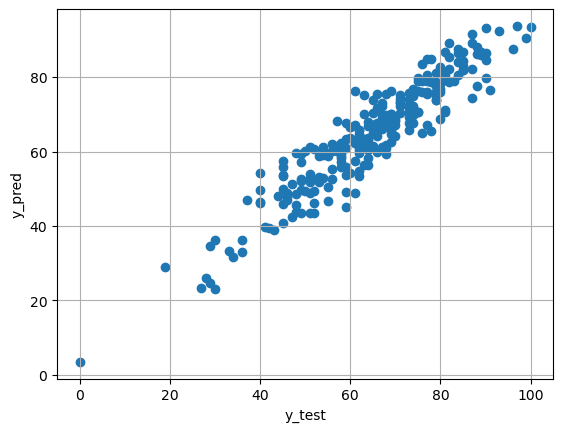

In [22]:
plt.scatter(y_test,y_pred)
plt.xlabel("y_test")
plt.ylabel("y_pred")
plt.grid()
plt.show()

<Axes: xlabel='math score'>

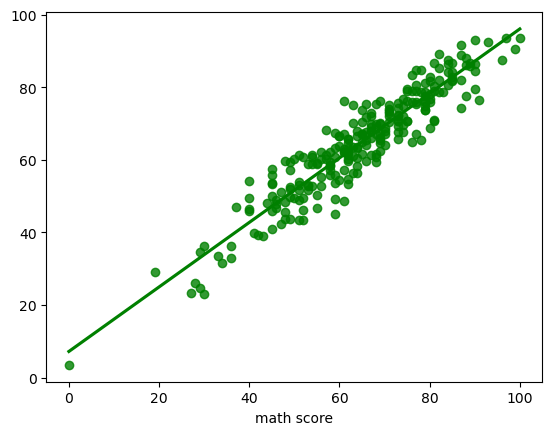

In [14]:
sns.regplot(x = y_test,y = y_pred,ci = None,color="green")

In [17]:
Ridge_model = Ridge(fit_intercept=True)
Ridge_model = lin_model.fit(X_train, y_train)
y_pred = Ridge_model.predict(X_test)
score = r2_score(y_test, y_pred) *100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 87.80


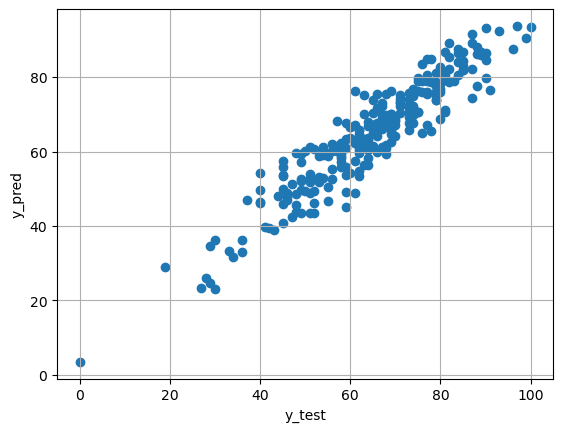

In [21]:
plt.scatter(y_test,y_pred)
plt.xlabel("y_test")
plt.ylabel("y_pred")
plt.grid()
plt.show()

<Axes: xlabel='math score'>

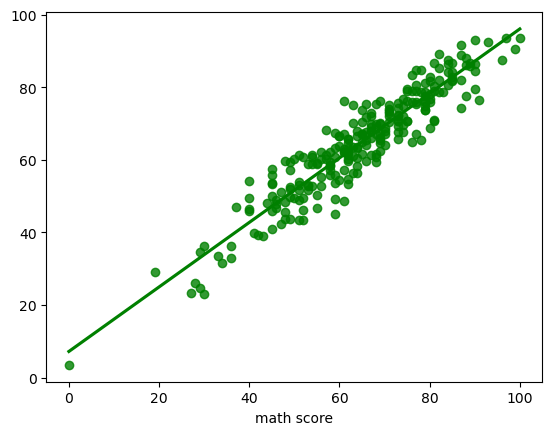

In [20]:
sns.regplot(x = y_test,y = y_pred,ci = None,color="green")